## 2.2 回归

接下来我们探讨被随机噪声污染的数据场景。噪声在物理实验（吴与滨田，2021）以及随机模拟（克莱宁，2008）中十分常见。针对这类含噪声数据，我们需要寻找具备拟合效果而非插值效果的模型。本书第三、四部分将大量运用此类方法。

### 2.2.1 线性回归

线性回归是统计学中主要的数据分析工具之一，已有诸多优质教材对该内容展开论述（法拉韦，2015、2016）。因此本文仅做简要介绍，引出部分便于后续构建试验设计的符号与概念。

再次考察式 (2.1) 中的同一一元函数，不过此时数据由下式生成：

$$
y_i = h(x_i) + \epsilon_i,\quad i = 1, \dots, n \tag{2.29}
$$

式中 $\epsilon_i$ 为其余未观测变量发生变动或是测量误差所带来的随机误差。假定通过开展 $n=20$ 次实验生成数据，实验设计选取区间 $[0,1]$ 内等间距分布的 10 个采样点，每个采样点重复实验两次。图 2.6 中绘制了测试函数（黑色虚线）与数据集 $\{(x_i, y_i)\}_{i=1}^{20}$（蓝色圆点）。

> **图 2.6** 采用 10 个等间隔设计点、两次重复试验开展多项式回归分析。左侧图像为三次多项式拟合结果，右侧为八次多项式拟合结果，阴影区域代表 95% 预测区间。

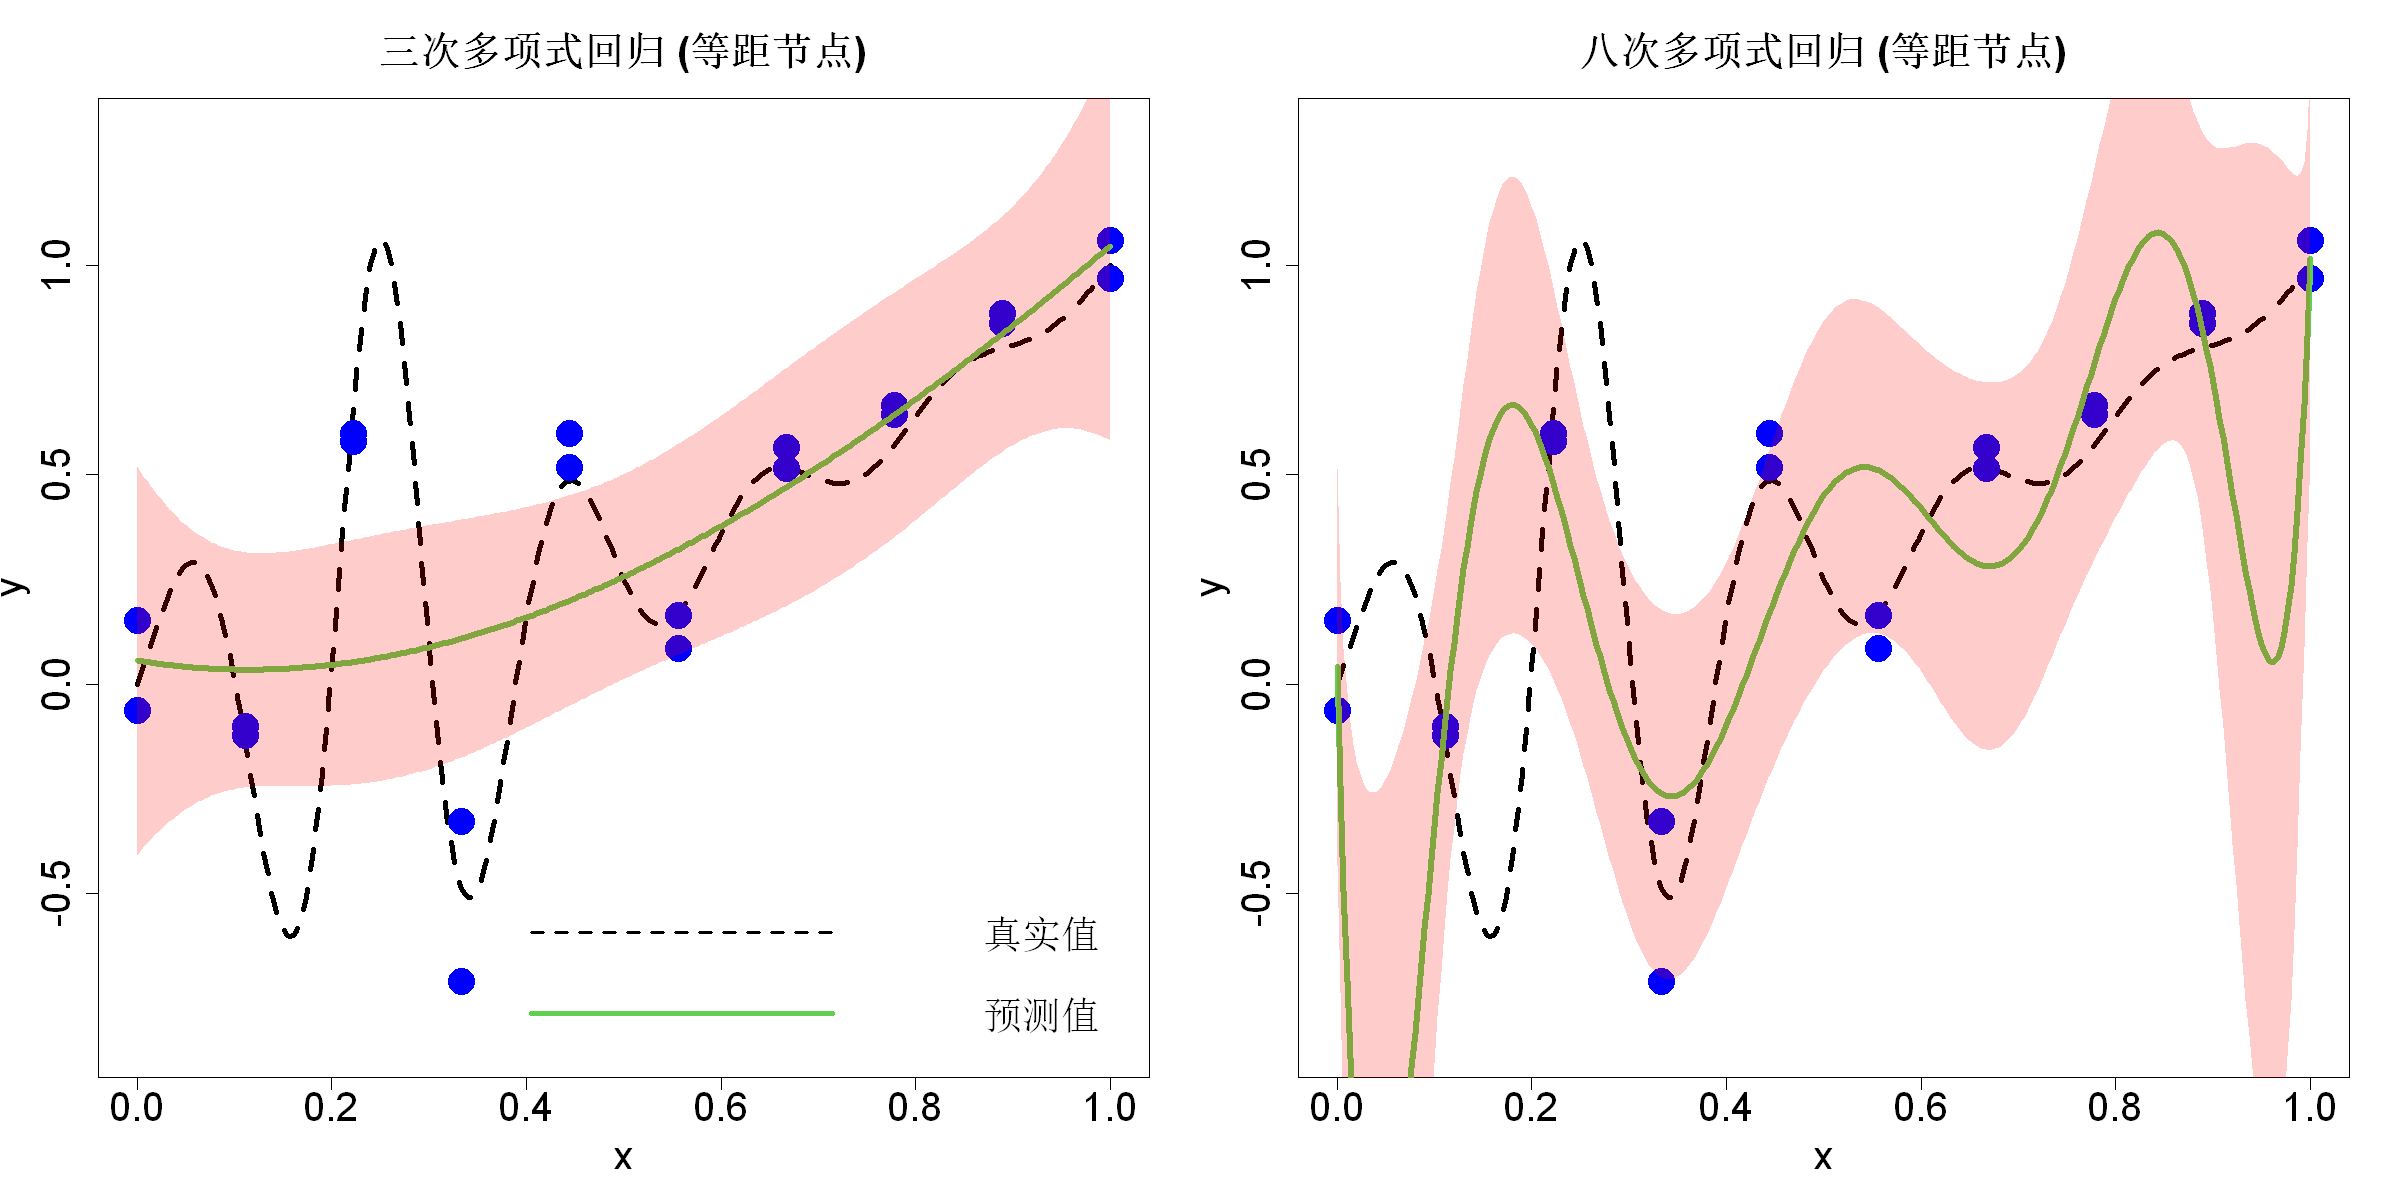

In [1]:
if(dir.exists("data")==FALSE) dir.create("data")
if((!file.exists("data/2.6-D.csv"))||(!file.exists("data/2.6-pred.csv"))){
  f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10;r=2
  D=rep(((1:n)-1)/(n-1),r) # 20x1
  set.seed(1)
  e=rnorm(n*r,sd=.1)
  y=f(D)+e # 20x1
  i1=3
  pred1=predict(lm(y~poly(D,i1)),newdata=data.frame(D=test),interval="confidence")
  mean1=pred1[,1] # 301x1
  lower1=pred1[,2] # 301x1
  upper1=pred1[,3] # 301x1
  i2=8
  pred2=predict(lm(y~poly(D,i2)),newdata=data.frame(D=test),interval="confidence")
  mean2=pred2[,1] # 301x1
  lower2=pred2[,2] # 301x1
  upper2=pred2[,3] # 301x1
  write.csv(data.frame(D=D,y=y),"data/2.6-D.csv")
  write.csv(data.frame(test=test,true=true,mean1=mean1,lower1=lower1,upper1=upper1,mean2=mean2,lower2=lower2,upper2=upper2),"data/2.6-pred.csv")
}

df_D=read.csv("data/2.6-D.csv")
D=df_D$D;y=df_D$y
pred=read.csv("data/2.6-pred.csv")
test=pred$test;true=pred$true
mean1=pred$mean1;lower1=pred$lower1;upper1=pred$upper1
mean2=pred$mean2;lower2=pred$lower2;upper2=pred$upper2

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="三次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(lower1,rev(upper1)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="八次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(lower2,rev(upper2)),col=adjustcolor("red",0.2),border=NA)

假设我们希望借助多项式

$$
y = \beta_0 + \beta_1x + \dots + \beta_mx^m
\tag{2.30}
$$

来近似函数 $h(x)$。线性回归方法将上述多项式视作真实模型，并假定数据由下式生成：

$$
y_i = \beta_0 + \beta_1x_i + \dots + \beta_mx_i^m + \epsilon_i,\quad i = 1,\dots,n
\tag{2.31}
$$

而非式 (2.29)。因此该方法忽略了多项式逼近 $h(x)$ 带来的偏差，而这一点对于不确定性量化有着重要影响。需要注意的是，尽管式 (2.31) 能够刻画非线性关系，但在统计学中它仍属于线性回归模型，原因是该模型关于参数向量 $\boldsymbol{\beta}=(\beta_0,\dots,\beta_m)'$ 呈线性形式。我们可以选取合适的参数，让拟合模型尽可能贴合实测数据。可以选用多种损失函数衡量模型与数据的“贴合程度”，其中最简单的是平方误差损失，这也是勒让德与高斯最初提出的方法。关于最小二乘法有趣的发展历史可参阅普拉凯特（1972 年）的文献。由此，优化问题可写为：

$$
\min_{\boldsymbol{\beta}} \sum_{i=1}^n \left\{y_i - [\beta_0 + \dots + \beta_mx_i^m]\right\}^2
$$

采用矩阵形式表述该优化问题：

$$
\min_{\boldsymbol{\beta}} (\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\beta})'(\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\beta})
$$

其中矩阵 $\boldsymbol{X}=\{x_i^{j-1}\}$ 是维度为 $n\times(m+1)$ 的模型设计矩阵。将目标函数对 $\boldsymbol{\beta}$ 求导并令导数等于零，可得正规方程：

$$
\boldsymbol{X}'\boldsymbol{X}\boldsymbol{\beta} = \boldsymbol{X}'\boldsymbol{y}
$$

若 $\boldsymbol{X}'\boldsymbol{X}$ 为非奇异矩阵，则存在唯一解：

$$
\hat{\boldsymbol{\beta}} = (\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'\boldsymbol{y}
\tag{2.32}
$$

在本例一维场景中，自变量 $x$ 仅有 10 个互不相同的采样点，想要保证矩阵 $\boldsymbol{X}$ 的列向量线性无关，多项式阶数 $m$ 必须满足 $m\le9$。

预测函数 $\hat{y}(x) = \boldsymbol{x}'\hat{\boldsymbol{\beta}}$（其中 $\boldsymbol{x} = (1, x, \dots, x_m)'$）在阶数 $m=3$ 与 $m=8$ 时的拟合曲线，在图 2.6 中以绿色实线绘制。相较于八次多项式拟合，三次多项式拟合在观测点处产生的偏差更大。但整体拟合效果上，三次多项式的拟合效果并不逊色于八次多项式，甚至表现更佳。

再进一步假设 $\epsilon_i$ 独立同分布，满足 $\epsilon_i\sim \mathcal{N}(0, \sigma^2)，i = 1, \dots, n$，不难证明：

$$
\hat{\boldsymbol{\beta}} \sim \mathcal{N}\left(\boldsymbol{\beta},\sigma^2(\boldsymbol{X}'\boldsymbol{X})^{-1}\right)
\tag{2.33}
$$

据此可求得预测值的方差：

$$
var\{\hat{y}(\boldsymbol{x})\} = var\{\boldsymbol{x}'\hat{\boldsymbol{\beta}}\} = \sigma^2\boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}
$$

该方差仅体现参数 $\boldsymbol{\beta}$ 估计过程带来的不确定性。由此可得新观测值预测结果的 95% 置信区间：

$$
\hat{y}(\boldsymbol{x}) \pm 2\sigma\sqrt{1 + \boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}}
$$

式中在原有方差基础上额外增加一项 $\sigma^2$，用以刻画新增扰动项 $\epsilon$ 带来的不确定性，该置信区间在图 2.6 中以阴影区域呈现。可以发现，三次多项式拟合对应的置信区间比八次多项式拟合的置信区间更窄，但三次多项式拟合在观测数据点附近存在更大的偏差；因此更窄的置信区间并不代表其预测精度更高。之所以出现这种不确定性刻画上的偏差，是因为我们在式 (2.31) 中错误假定三次多项式为真实模型。这是线性回归模型的一大缺陷，后续两个小节介绍的非参数回归模型可以解决该问题。

在继续展开分析前，我们先来探究能否借助试验设计方法优化线性回归的拟合效果。若回归系数估计量 $\hat{\boldsymbol{\beta}}$ 的方差足够小，那么系数 $\boldsymbol{\beta}$ 的估计结果就会具备较高精度。由于 $\sigma^2$ 为常数，该目标等价于最小化矩阵 $(\boldsymbol{X}'\boldsymbol{X})^{-1}$。为实现最小化目标，学者们提出了若干具备实际意义的标量优化准则（瓦尔德，1943；埃尔夫温，1952；基弗、沃尔福威茨，1960）。应用最为广泛的准则是矩阵 $(\boldsymbol{X}'\boldsymbol{X})^{-1}$ 的行列式，该行列式能够表征系数估计量 $\hat{\boldsymbol{\beta}}$ 置信椭球的体积。因此求解最优设计的问题可写为：

$$
\begin{align*}
\min_D |(\boldsymbol{X}'\boldsymbol{X})^{-1}|&=\min_D 1/|\boldsymbol{X}'\boldsymbol{X}|\\
&\equiv\max_D |\boldsymbol{X}'\boldsymbol{X}|
\tag{2.34}
\end{align*}
$$

该最优设计被称为 D 最优设计，字母 D 代表行列式（determinant）。另一常用准则是最小化各系数估计量 $\hat{\beta}_i$ 的方差之和，也就是矩阵 $(\boldsymbol{X}'\boldsymbol{X})^{-1}$ 的迹：

$$
\min_D tr\left[(\boldsymbol{X}'\boldsymbol{X})^{-1}\right]
\tag{2.35}
$$

满足该准则的设计称作 A 最优设计。上述两类准则均以精准估计系数 $\boldsymbol{\beta}$ 为核心，进而间接提升模型预测效果。我们也可构建直接面向预测效果的优化准则。G 最优设计通过在整个定义域 $\mathcal{X}$ 上最小化最大预测方差得到：

$$
\min_D \max_{\boldsymbol{x}\in\mathcal{X}} \boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}
\tag{2.36}
$$

而 I 最优设计则是对预测方差做积分平均后再进行最小化求解：

$$
\min_D \int_{\boldsymbol{x}\in\mathcal{X}}\boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}d\boldsymbol{x}
\tag{2.37}
$$

有关最优设计的更多详细内容可参阅普克尔舍姆（1993）、西尔维（1980）、阿特金森等人（2007）以及洛佩斯-菲达尔戈（2023）的专著；古斯与琼斯（2011）针对该主题给出了更贴合实际应用的讲解。

想要优化上述设计准则并非易事，原因在于目标函数具备非线性、多模态的特征，且计算成本高昂。因此，通用优化算法处理该问题时效果欠佳。解决这类问题最常用的手段是采用各类互换算法：即给定初始设计方案 D 与候选集合 C，若目标函数能够得到优化，便将设计方案 D 中的某一行与候选集合 C 中的某一行进行互换。此类算法最终只会收敛至局部最优解，故而需要设置多组初始设计方案，才有可能求解出全局最优设计。下文将介绍用于构造 D 最优设计的费多罗夫互换算法（费多罗夫，1972年）。其他互换算法的详细内容可参考库克与纳赫茨海姆（1980）、阮与米勒（1992）的相关研究。

设 $\boldsymbol{x}_i$ 为矩阵 $\boldsymbol{X}$ 的第 $i$ 行，即 $\boldsymbol{X}=(\boldsymbol{x}_1',\dots,\boldsymbol{x}_n')'$，则 $\boldsymbol{X}'\boldsymbol{X}=\sum_{i=1}^n \boldsymbol{x}_i\boldsymbol{x}_i'$。假设将行向量 $\boldsymbol{x}_i$ 与候选集合 $\mathcal{C}$ 中的某一行向量 $\boldsymbol{c}$ 互换，得到新的模型矩阵 $\boldsymbol{X}_{new}$，此时 D 最优目标函数满足 $|\boldsymbol{X}_{new}'\boldsymbol{X}_{new}|=|\boldsymbol{X}'\boldsymbol{X}+\boldsymbol{c}\boldsymbol{c}' -\boldsymbol{x}_i\boldsymbol{x}_i'|$。我们需要确定将哪个 $\boldsymbol{x}_i$ 与集合 $\mathcal{C}$ 中的向量 $\boldsymbol{c}$ 进行互换。下述矩阵结论可用于简化计算，其中第二条即为谢尔曼-莫里森矩阵恒等式。

> **引理 2.4** 若 $\boldsymbol{A}$ 为 $m\times m$ 阶矩阵，$\boldsymbol{a}$ 为 $m\times 1$ 维向量，则
> $$|\boldsymbol{A}+\boldsymbol{a}\boldsymbol{a}'|=|\boldsymbol{A}|(1+\boldsymbol{a}'\boldsymbol{A}^{-1}\boldsymbol{a})$$
> $$(\boldsymbol{A}+\boldsymbol{a}\boldsymbol{a}')^{-1}=\boldsymbol{A}^{-1}-\frac{\boldsymbol{A}^{-1}\boldsymbol{a}\boldsymbol{a}'\boldsymbol{A}^{-1}}{1+\boldsymbol{a}'\boldsymbol{A}^{-1}\boldsymbol{a}}$$

将第一个矩阵结论运用两次：

$$
\begin{align*}
|\boldsymbol{X}_{new}'\boldsymbol{X}_{new}|&=|\boldsymbol{X}'\boldsymbol{X}+\boldsymbol{c}\boldsymbol{c}'-\boldsymbol{x}_{i}\boldsymbol{x}_{i}'|\\
&=|\boldsymbol{X}'\boldsymbol{X}+\boldsymbol{c}\boldsymbol{c}'|\{1-\boldsymbol{x}_{i}'(\boldsymbol{X}'\boldsymbol{X}+\boldsymbol{c}\boldsymbol{c}')^{-1}\boldsymbol{x}_{i}\}\\
&=|\boldsymbol{X}'\boldsymbol{X}|(1+\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{c})\{1-\boldsymbol{x}_{i}'(\boldsymbol{X}'\boldsymbol{X}+\boldsymbol{c}\boldsymbol{c}')^{-1}\boldsymbol{x}_{i}\}
\end{align*}
$$

再代入第二个矩阵结论并化简可得：

$$
\begin{align*}
|\boldsymbol{X}_{new}'\boldsymbol{X}_{new}|&=|\boldsymbol{X}'\boldsymbol{X}|(1+\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{c})\left\{1-\boldsymbol{x}_{i}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}_{i}+\frac{\{\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}_{i}\}^{2}}{1+\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{c}}\right\}\\
&=|\boldsymbol{X}'\boldsymbol{X}|\{1+\Delta(\boldsymbol{x}_{i},\boldsymbol{c})\}
\end{align*}
$$

其中

$$
\Delta(\boldsymbol{x}_{i},\boldsymbol{c})=\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{c}-\boldsymbol{x}_{i}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}_{i}\{1+\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{c}\}+\{\boldsymbol{c}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}_{i}\}^{2}
$$

通过最大化 $\Delta(\boldsymbol{x}_i,\boldsymbol{c})$ 即可求得最优替换方案，该方式的计算成本远低于直接计算 $|\boldsymbol{X}'\boldsymbol{X} + \boldsymbol{c}\boldsymbol{c}' - \boldsymbol{x}_i\boldsymbol{x}_i'|$。可持续执行此类替换操作直至结果不再优化。该算法已在 R 语言程序包 AlgDesign（惠勒、布劳恩，2024）中实现。

再次回顾一维实例。若想要得到 10 个互不相同的点，可取参数 $m=9$。为构造候选点集，先在区间 $[0,1]$ 上选取 301 个等距节点，随后构造向量 $c_j = (1, c_j, \dots, c_j^9)$，其中 $j=1,2,\dots,301$。随后借助 AlgDesign 程序包中的 optFederov 函数求解得到 D 最优设计，设计点结果绘制于图 2.7 中。可以观察到，生成的节点向区间两端边界靠拢。两组多项式拟合效果相比之前有所提升，尤其是八次多项式在边界处剧烈震荡的现象已经消失。

> **图 2.7** 采用 10 个 D 最优设计点并设置两组重复试验的多项式回归。左侧图表为三次多项式拟合结果，右侧为八次多项式拟合结果，阴影区域代表 95% 预测区间。

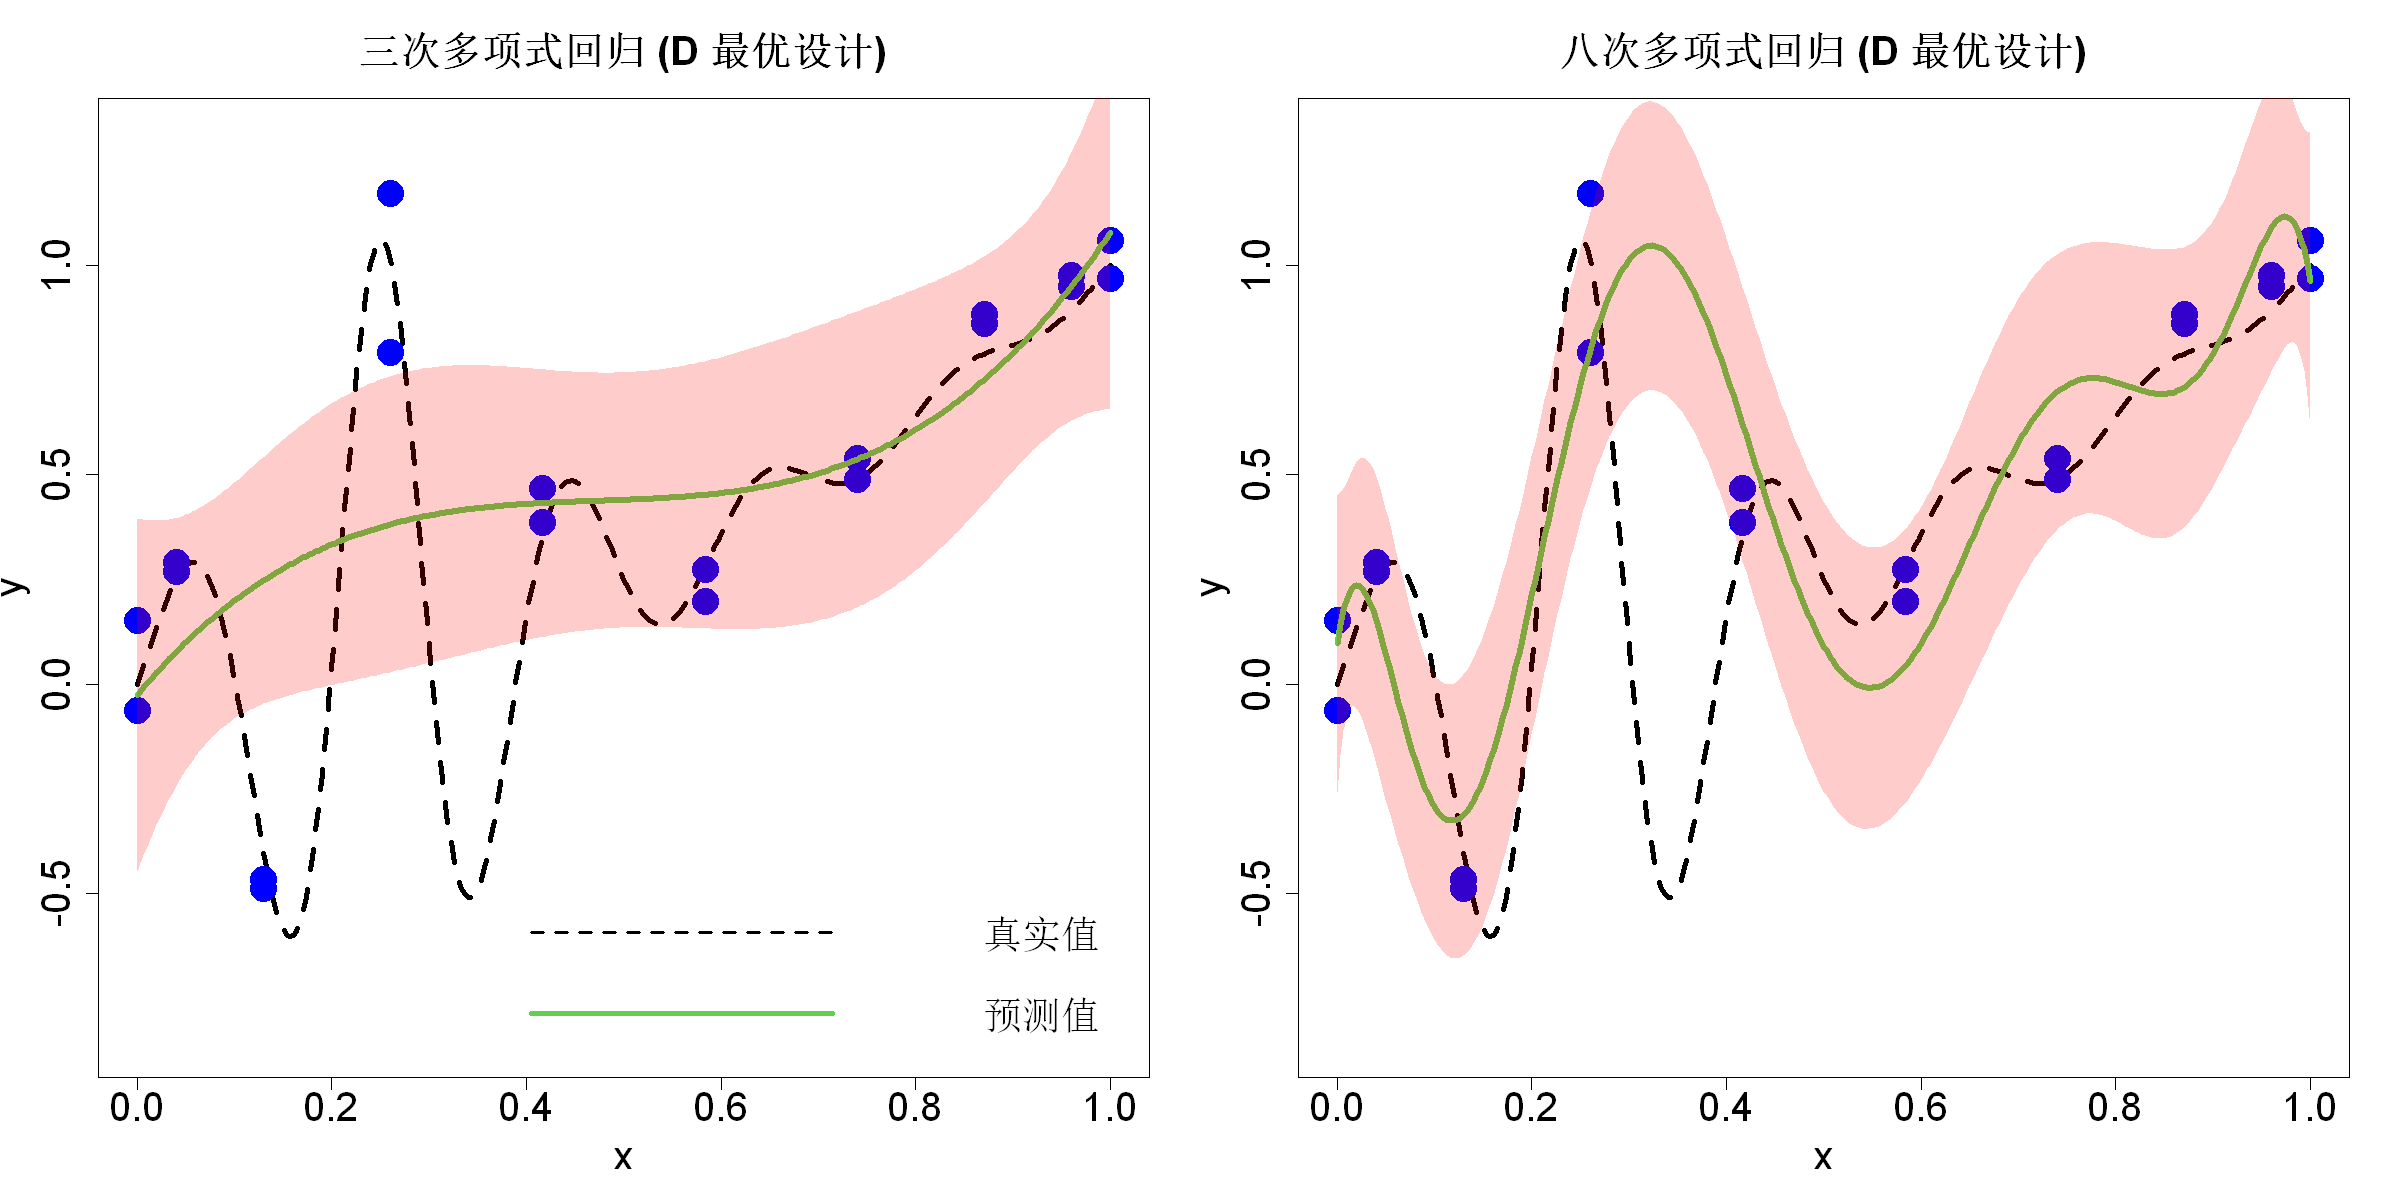

In [2]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/2.7-D.csv"))||(!file.exists("data/2.7-pred.csv"))){
  f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10;r=2
  tests=2*test-1 # 301x1
  cand_df=data.frame(x=tests)
  library(AlgDesign)
  a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
  D=(rep(c(a$design[,1]),r)+1)/2 # 20x1
  set.seed(1)
  e=rnorm(n*r,sd=.1)
  y=f(D)+e # 20x1
  i1=3
  pred1=predict(lm(y~poly(D,i1)),newdata=data.frame(D=test),interval="confidence")
  mean1=pred1[,1]
  upper1=pred1[,2]
  lower1=pred1[,3]
  i2=8
  pred2=predict(lm(y~poly(D,i2)),newdata=data.frame(D=test),interval="confidence")
  mean2=pred2[,1]
  upper2=pred2[,2]
  lower2=pred2[,3]
  write.csv(data.frame(D=D,y=y),file="data/2.7-D.csv",row.names=FALSE)
  write.csv(data.frame(test=test,true=true,mean1=mean1,upper1=upper1,lower1=lower1,mean2=mean2,upper2=upper2,lower2=lower2),file="data/2.7-pred.csv",row.names=FALSE)
}

df_D=read.csv("data/2.7-D.csv")
D=df_D$D;y=df_D$y
pred=read.csv("data/2.7-pred.csv")
test=pred$test
true=pred$true
mean1=pred$mean1;upper1=pred$upper1;lower1=pred$lower1
mean2=pred$mean2;upper2=pred$upper2;lower2=pred$lower2

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="三次多项式回归 (D 最优设计)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(upper1,rev(lower1)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="八次多项式回归 (D 最优设计)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(upper2,rev(lower2)),col=adjustcolor("red",0.2),border=NA)

仔细观察图 2.7 中的设计点与图 2.1 中的切比雪夫节点可以发现，二者位置高度相近。这并非巧合！德特与斯图登（1992）证明：D 最优设计的经验分布收敛于反正弦密度函数：

$$
f(x) = \frac{1}{\pi\sqrt{x(1-x)}},\quad x\in[0,1]
$$

或者

$$
f(x) = \frac{1}{\pi\sqrt{1-x^2}},\quad x\in[-1,1] \tag{2.38}
$$

本书第 5 章将介绍用于拟合分布的试验设计，此处先采用简便方法。众所周知，点集 $\{0.5/n, 1.5/n,\dots,(n-0.5)/n\}$ 是区间 $[0,1]$ 上逼近均匀分布的最优 $n$ 个点位。结合逆概率变换法（5.2.1节），即可求出逼近反正弦密度的最优点位。当$x\in[-1,1]$时，分布函数为：

$$
F(x)=\int_{-1}^{x}\frac{1}{\pi\sqrt{1-t^2}}dt=1-\frac{1}{\pi}\arccos x
$$

其逆函数为 $F^{-1}(x)=\cos\left(\pi(1-x)\right)$。由于 $\{(i-0.5)/n\}_{i=1}^n$、$\{(n-i+0.5)/n\}_{i=1}^n$ 是均匀分布的最优代表点，对均匀分布点位做逆概率变换 $\{F^{-1}\left((n-i+0.5)/n\right)\}_{i=1}^n$，得到的点位恰好就是式 (2.5) 定义的切比雪夫节点。也就是说，当 $n$ 足够大时，用于拟合 $n-1$ 次多项式的 D 最优设计点，完全可以用切比雪夫节点近似替代。这就在试验设计与逼近理论两大领域之间建立了巧妙的关联。

现在考虑包含多个输入变量的情形。仅纳入变量主效应的线性回归模型可写为：

$$
y = \beta_0 + \beta_1x_1 + \dots + \beta_px_p + \epsilon
$$

我们还可以引入多项式项 $x_j^2、x_j^3\cdots$（$j=1,\dots,p$）、二阶交互项 $x_ix_j、x_ix_j^2\cdots$，以及高阶交互项 $x_ix_jx_k\cdots$。因此，线性回归模型中可纳入的效应总数 $P$ 可以非常大，甚至远大于样本量 $n$。设 $\boldsymbol{X}$ 为 $n\times P$ 的模型矩阵，则 $\boldsymbol{X}^\prime\boldsymbol{X}$ 的秩满足 $\text{rank}(\boldsymbol{X}^\prime\boldsymbol{X}) = n < P$，无法像式 (2.32) 中那样对 $\boldsymbol{X}^\prime\boldsymbol{X}$ 求逆以得到最小二乘估计。我们可以通过岭回归（霍尔、肯纳德，1970）解决该问题。假设矩阵 $\boldsymbol{X}$ 的各列与响应变量 $\boldsymbol{y}$ 均经过标准化处理，均值为 0、标准差为 1，接下来考虑不含截距项的回归模型。岭回归求解如下优化问题：

$$
\min_{\boldsymbol{\beta}} (\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta})^\prime(\boldsymbol{y}-\boldsymbol{X}\boldsymbol{\beta}) + \lambda\boldsymbol{\beta}^\prime\boldsymbol{\beta}
\tag{2.39}
$$

其中 $\lambda>0$ 为正则化参数，对应的解为：

$$
\hat{\boldsymbol{\beta}} = (\boldsymbol{X}^\prime\boldsymbol{X} + \lambda\boldsymbol{I}_P)^{-1}\boldsymbol{X}^\prime\boldsymbol{y}
\tag{2.40}
$$

正则化参数 $\lambda$ 可通过交叉验证法选定。下面的结论有助于推导留一交叉验证误差。记帽子矩阵 $\boldsymbol{L}= \boldsymbol{X}(\boldsymbol{X}^\prime\boldsymbol{X}+\lambda\boldsymbol{I}_P)^{-1}\boldsymbol{X}^\prime$，则留一交叉验证误差 $y_i - \hat{y}_{\sim i}$ 可借助简便公式计算（瓦瑟曼，2006，第 70 页）。

> **引理 2.5** 对于线性预测值 $\hat{\boldsymbol{y}} = \boldsymbol{L}\boldsymbol{y}$，留一交叉验证误差可通过下式计算：
> $$cv_i = \frac{y_i - \hat{y}_i}{1 - l_i},\quad i = 1, \dots, n$$
> 其中 $l_i = \boldsymbol{L}_{ii}$ 为帽子值（也称杠杆值）。

因此，均方交叉验证误差的表达式为：$MSCV = \sum_{i=1}^{n} cv_i^2/n$。戈卢布等人（1979）提出了一种均方交叉验证误差的近似形式，称为广义交叉验证（GCV），其公式如下：

$$
GCV = \frac{1}{n}\frac{\sum_{i=1}^{n}(y_i -\hat{y}_i)^2}{(1 -\bar{l})^2}
$$

其中 $\bar{l} = \sum_{i=1}^{n} l_i/n = tr\{(\boldsymbol{X}'\boldsymbol{X} + \lambda \boldsymbol{I}_P )^{-1}\boldsymbol{X}'\boldsymbol{X}\}/n$。广义交叉验证具备优良性质，例如模型矩阵具有旋转不变性。因此，可以通过最小化均方交叉验证误差或广义交叉验证的值，利用数据求解得到参数 $\lambda$。

然而，式 (2.40) 中的岭回归仅包含单一正则化参数 $\lambda$，这隐含假定主效应、二因子交互效应等各类效应具有同等重要性。但在实际应用中，该假设几乎无法成立。因此，我们需要对岭回归表达式进行修正，使其适用于试验数据分析。为此，首先需要引入效应分层原理、效应遗传原理等试验设计准则（吴与滨田，2021）。相关内容将在第 8 章探讨实体试验数据分析时展开介绍。